# RAPID-MFA-6a: Changing lifetimes: one-off change

## Descriptions
The basic dynamic MFA models in `RAPID-MFA-1: The flow driven model` and `RAPID-MFA-2: The stock driven model` assume that all cohorts have the same survival curve, but this doesn't have to be the case.

In this notebook, the inflow cohorts before a certain timeframe have one survival curve, and the inflow cohorts after than timeframe have a different survival curve. This describes cases such as a new technology or a new policy implemented for new inflows from a certain point onwards. It's called the "cohort effect" of lifetimes in [Krych et al. (2025). The “nature” and “nurture” of product lifetimes in dynamic stock modeling](https://onlinelibrary.wiley.com/doi/abs/10.1111/jiec.13586).

This model takes the following inputs:

- A _stock_ time series of the product.
- The _older cohorts' survival curve_.
- The  _newer cohorts' survival curve_.
- The _'switchpoint' timeframe_ in which the lifetime changes from the old to the new survival curve. 

It produces the standard two main model outputs:
- The _stocks_ time series.
- The _outflows_ time series.

And two auxiliary model outputs:
- The _cohorts survival matrix_ table.
- The _stock changes_ (net addition to stock) time series.

In this example, vehicles that entered the fleet from 2018 follow a new safety regulation, whose effect is that more vehicles survive the first few years of use, but as they age they deteriorate faster than before.

### Notes
1. The only true modification in this model is in the creation of the survival curves matrix in cell 4.
1. This modeling concept can be extended to multiple changes to the survival curves in different timeframes by adding more 'switch points'. The extreme case is one in which each cohort has its own unique survival curve, as exemplified in `RAPID-MFA-6b: Changing lifetimes: continuously varying lifetimes`.
1. This example uses the stock-driven model, but it can be replaced with the flow driven model. 
1. This example uses a Weibull distribution for the old survival curve and a normal distribution for the new survival curve, but both can be replaced with any other curves.
1. Please also read the notes and other details of the notebooks listed in “Relations with other RAPID-MFA notebooks”

### Exogenous variables
__Stocks:__ Number of plug-in and electric vehicles for years 1998 to 2050 in the USA. Adapted, modified and simplified from [Fishman et al. 2018](https://doi.org/10.3390/resources7010009).

__Old survival curve:__ Weibull distribution, $shape=2.4$, $scale=16.9$, from [Fishman et al. 2018](https://doi.org/10.3390/resources7010009).

__New survival curve:__ Normal distribution, using mock values purposefully chosen to be different from the old survival curve.


### Relations with other RAPID-MFA notebooks
- `RAPID-MFA-2: The stock driven model`: The basic model to calculate flows and stocks for this example. Can be swapped with a flow-driven model, see notes above.
- `RAPID-MFA-6b: Changing lifetimes: continuously varying lifetimes`: shows evolutions of survival curves changing through time, instead of a single radical change from one timeframe onward.

## Version, licence and how to cite

Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This notebook was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 

## 1. Load libraries

In [89]:
# %% 1. Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sns

## 2. Define example input data

In [90]:
# %% 2. Define example input data
input_data = pd.Series([0, 17, 9367, 29639, 65611, 112994, 196655, 405237, 655629, 1002834, 
                        1307203, 1584131, 1836332, 2092277, 2537144, 3074043, 3567853, 4207156, 
                        4945879, 5797925, 6778277, 7902746, 9187646, 10649295, 12303394, 14164318, 
                        16244276, 18552466, 21094228, 23870337, 26876417, 30102657, 33533764, 
                        37149274, 40924083, 44829315, 48833234, 52902345, 57002464, 61099726, 
                        65161509, 69157195, 73058775, 76841335, 80483330, 83966772, 87277263, 
                        90403948, 93339367, 96079253, 98622261, 100969690, 103125124], 
                       name = 'stocks', 
                       index = [1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 
                                2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 
                                2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 
                                2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 
                                2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 
                                2048, 2049, 2050])  

switchpoint_timeframe = 2018 # Timeframe of the change of the survival curves

# Parameters for the survival curves
ages = range(0, len(input_data))

shape_old = 2.428914875
scale_old = 16.93851375

mean_new = 16
std_dev_new = 3

#shape_new = 2.834573234
#scale_new = 23.25751

# Create the survival curves for the old and the new lifetimes
survival_curve_old = scipy.stats.weibull_min.sf(ages, shape_old, 0, scale_old)

survival_curve_new = scipy.stats.norm.sf(ages, loc=mean_new, scale=std_dev_new)


### 2.1 Plot the survival curves

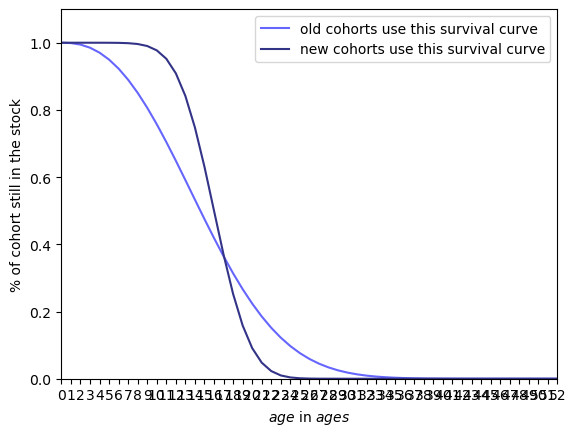

In [91]:
plt.plot(ages, survival_curve_old,  color='#6666ff', label='old cohorts use this survival curve')
plt.plot(ages, survival_curve_new,  color='#333388', label='new cohorts use this survival curve')
plt.xlabel('$\it{age}$ in $\it{ages}$')
plt.ylabel('% of cohort still in the stock')
plt.xticks(ages)
plt.xlim(0,ages[-1])
plt.ylim(0,1.1)
plt.legend()

## 3. Set up the MFA system

In [92]:
# %% 3. Set up the MFA system
units = {'time_interval': 'year', 
         'flows': 'vehicles/year', 
         'stocks': 'vehicles'
         }

timeframes = cohorts = input_data.index  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because there is one inflow per time interval.
time_interval = 1
cohort_stop = (cohorts[-1] + time_interval)  # because of exclusive slicing in python, an extra time interval is required
mfa_system = pd.DataFrame(index=timeframes, columns = ['stocks', 
                                                                         'inflows', 
                                                                         'outflows', 
                                                                         'stock_changes'])

mfa_system['stocks'] = input_data

### 4. Create the survival curves matrix

This is where the code differs from the basic MFA model: create a survival curve matrix that has the old survival curve for the 1998-2024 cohorts and the new survival curve for the 2025-2050 cohorts.

Note that _cohorts_ is a list-like datatype, so it can't be sliced by its contents e.g. cohorts[1998:2025], only by its indices e.g. cohorts[0:27], so the index of the switchpoint needs to be obtained.

[Text(0.5, 23.52222222222222, "Cohorts (each inflow's own survival)"),
 Text(50.722222222222214, 0.5, 'Timeframe (how much of each inflow is still in stock)')]

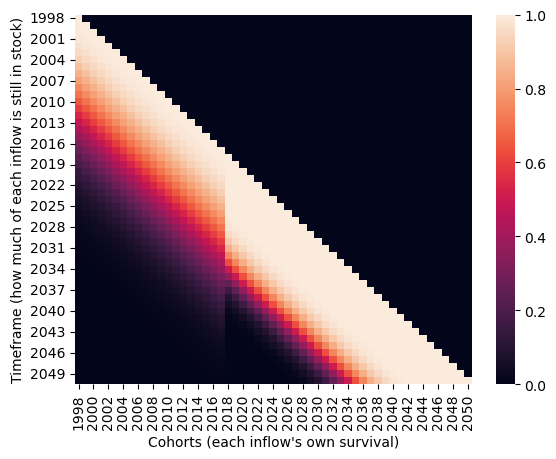

In [93]:
# %%% 4. Create the survival curves matrix

# create survival curves matrix filled with zeros
# no changes here!
survival_curves_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# create a survival curve matrix that has the old survival curve for the 1998-2024 cohorts and the new survival curve for the 2025-2050 cohorts

# get the index of the switchpoint timeframe
# cohorts is a list-like datatype, so it can't be sliced by its contents like cohorts[1998:2025], only by its indices like cohorts[0:27].
switchpoint_index = switchpoint_timeframe - cohorts[0]

# populate that matrix
for cohort in cohorts[0 : switchpoint_index]:
   survival_curves_matrix.loc[cohort: , cohort] = survival_curve_old[0 : cohort_stop - cohort]
for cohort in cohorts[switchpoint_index : ]:
    survival_curves_matrix.loc[cohort: , cohort] = survival_curve_new[0 : cohort_stop - cohort]

# visualize the survival_curve_matrix with a heatmap
sns.heatmap(survival_curves_matrix, annot=False).set(xlabel ="Cohorts (each inflow's own survival)", ylabel = "Timeframe (how much of each inflow is still in stock)")

### 5. Calculate the MFA system
Identical to the code of the original stock-driven model

In [94]:
# %% 5. Calculate the MFA system

# Create cohorts survival matrix and calculate the inflows

# initialize the cohort_survival_matrix filled with zeros
cohorts_survival_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)
# And populate it
for cohort in cohorts:
    # calculate the inflow of the time-th year
    mfa_system.loc[cohort, 'inflows'] = (
        mfa_system.loc[cohort, 'stocks'] - cohorts_survival_matrix.loc[cohort, : cohort - 1].sum()
    ) / survival_curves_matrix.loc[cohort, cohort]
    # now that the time-th inflow is known, scale the shifted survival curve with this inflow
    cohorts_survival_matrix.loc[:, cohort] = survival_curves_matrix.loc[:, cohort] * mfa_system.loc[cohort, 'inflows']

# calculate stock changes (net change to stock)
mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)
# Calculate outflows using mass balance
mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]

### Diagnostics: comparison with a case without changes to lifetimes

Running the basic dynamic MFA with only the old survival curve for all cohorts can show what has changed.

In [95]:
# %% Comparison MFA system with only the old survival curve for all cohorts
mfa_system_basic = pd.DataFrame(index=timeframes, columns = ['stocks', 
                                                                         'inflows', 
                                                                         'outflows', 
                                                                         'stock_changes'])
mfa_system_basic['stocks'] = input_data

# create survival curves matrix filled with zeros
survival_curves_matrix_basic = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)
# populate that matrix
for cohort in cohorts:
   survival_curves_matrix_basic.loc[cohort: , cohort] = survival_curve_old[0 : cohort_stop - cohort]
# Calculate the MFA system
# initialize the cohort_survival_matrix filled with zeros
cohorts_survival_matrix_basic = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)
# And populate it
for cohort in cohorts:
    # calculate the inflow of the time-th year
    mfa_system_basic.loc[cohort, 'inflows'] = (
        mfa_system_basic.loc[cohort, 'stocks'] - cohorts_survival_matrix_basic.loc[cohort, : cohort - 1].sum()
    ) / survival_curves_matrix_basic.loc[cohort, cohort]
    # now that the time-th inflow is known, scale the shifted survival curve with this inflow
    cohorts_survival_matrix_basic.loc[:, cohort] = survival_curves_matrix_basic.loc[:, cohort] * mfa_system_basic.loc[cohort, 'inflows']
# calculate stock changes (net change to stock)
mfa_system_basic["stock_changes"] = np.diff(mfa_system_basic["stocks"], prepend=0)
# Calculate outflows using mass balance
mfa_system_basic["outflows"] = mfa_system_basic["inflows"] - mfa_system_basic["stock_changes"]


<Axes: ylabel='vehicles'>

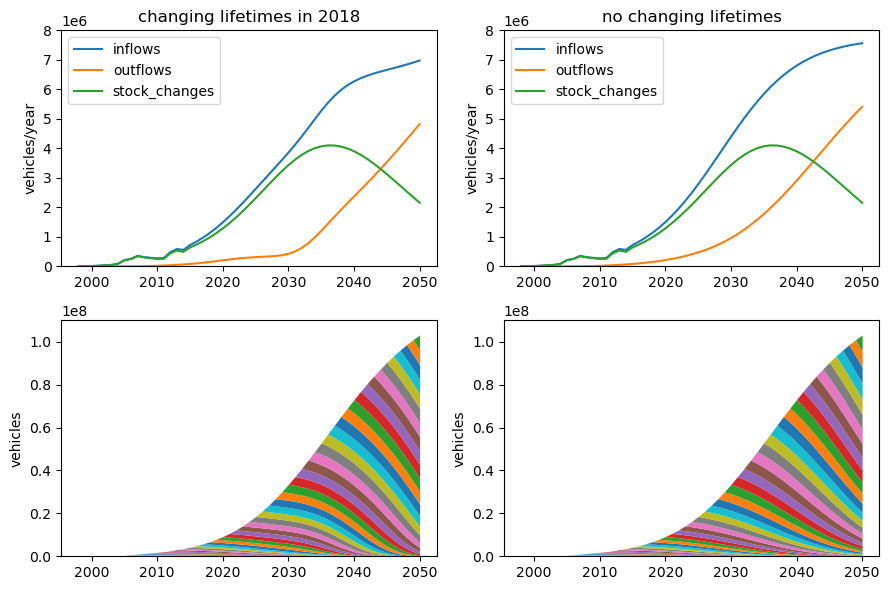

In [96]:
# visualize the comparisons

compare_fig, compare_ax = plt.subplots(nrows=2, ncols=2, figsize=(9, 6), tight_layout=True)
mfa_system[["inflows", "outflows", "stock_changes"]].plot(ylabel=units['flows'], ax=compare_ax[0,0], ylim=(0, 8e6), title="changing lifetimes in 2018")
mfa_system_basic[["inflows", "outflows", "stock_changes"]].plot(ylabel=units['flows'], ax=compare_ax[0,1], ylim=(0, 8e6), title="no changing lifetimes")
cohorts_survival_matrix.plot(kind="area", stacked=True, legend = False, lw=0, ylabel=units['stocks'], ax=compare_ax[1,0], ylim=(0, 11e7))
cohorts_survival_matrix_basic.plot(kind="area", stacked=True, legend = False, lw=0, ylabel=units['stocks'], ax=compare_ax[1,1], ylim=(0, 11e7))

If the lifetimes weren't changed, there would be more inflows and outflows.
The stocks don't differ (because they're data inputs) but their compositions change.
